In [2]:
from constants import DATA_ROOT_PATH_NAME, BANDPASS, HAMPEL_WINDOW_SIZE, HAMPEL_N_SIGMA, CROP_TMIN, CROP_TMAX, LOCAL_DETREND_WINDOW_SEC, LOCAL_DETREND_STEP_SEC, ASR_CUTOFF, ASR_BLOCKSIZE, ASR_WIN_LEN, ASR_WIN_OVERLAP, ASR_MAX_DROPOUT_FRACTION, ASR_MIN_CLEAN_FRACTION, ASR_MAX_BAD_CHANS

from preprocessing.step.bandpass import BandpassFilterStep
from preprocessing.step.detrend import LocalDetrendStep
from preprocessing.step.hampel import HampelFilterStep
from preprocessing.step.asr import ASRStep
from preprocessing.step.crop import CropStep

from preprocessing.pipeline import PreprocessingPipeline
import numpy as np

from features.factory import CompleteFeatureExtractionEngine, FeatureExtractionConfig
from features.categories import FeatureCategory
from features.dataset import SingleParticipantProcessedFeatureDatasetFactory
from features.io import FeaturesDatasetIO, SingleParticipantProcessedFeatureDatasetIO

from eeg.data import EEGRecordedDataProvider

from features.visualization import TopomapFactory



%load_ext autoreload
%autoreload 2

# Création des 2 datasets de features

In [5]:
recordings = EEGRecordedDataProvider.build(DATA_ROOT_PATH_NAME)

/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-eyesclosed.

The search_str was "data/sub-001/**/eeg/sub-001*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 57
Group: A
MMSE: 16
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-002_task-eyesclosed.

The search_str was "data/sub-002/**/eeg/sub-002*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 78
Group: A
MMSE: 22
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not fin

In [6]:
asr_pipeline = PreprocessingPipeline(name="ASR",
                                        steps=[
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                ASRStep(cutoff=ASR_CUTOFF, blocksize=ASR_BLOCKSIZE, win_len=ASR_WIN_LEN, win_overlap=ASR_WIN_OVERLAP, max_dropout_fraction=ASR_MAX_DROPOUT_FRACTION, min_clean_fraction=ASR_MIN_CLEAN_FRACTION, max_bad_chans=ASR_MAX_BAD_CHANS)
                                                ])

dethamp_pipeline = PreprocessingPipeline(name="det-hamp",
                                        steps=[ 
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                LocalDetrendStep(window_sec=LOCAL_DETREND_WINDOW_SEC, step_sec=LOCAL_DETREND_STEP_SEC),
                                                HampelFilterStep(window_size=HAMPEL_WINDOW_SIZE, n_sigma=HAMPEL_N_SIGMA)
                                                ])

In [ ]:
categories_to_extract = [FeatureCategory.WAVELET, FeatureCategory.TEMPORAL, FeatureCategory.POWER_RATIO, FeatureCategory.SPECTRAL]
config = FeatureExtractionConfig(categories_to_extract=categories_to_extract, wamp_threshold=10e-9, ppc_epoch_duration=2)
feature_extraction_engine = CompleteFeatureExtractionEngine(config=config)

In [19]:
for recording in recordings :
    asr_processed_eeg = asr_pipeline.compute(recording)
    dethamp_processed_eeg = dethamp_pipeline.compute(recording)

    dethamp_processed_extraction_result = feature_extraction_engine.extract(dethamp_processed_eeg)
    asr_processed_extraction_result = feature_extraction_engine.extract(asr_processed_eeg)

    dethamp_feature_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(dethamp_processed_extraction_result.feature_result, dethamp_processed_extraction_result.psd_result, dethamp_processed_extraction_result.ppc_result)

    asr_feature_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(asr_processed_extraction_result.feature_result, asr_processed_extraction_result.psd_result, asr_processed_extraction_result.ppc_result)

    
    SingleParticipantProcessedFeatureDatasetIO.export(dethamp_feature_dataset, "computed_data/dethamp")
    SingleParticipantProcessedFeatureDatasetIO.export(asr_feature_dataset, "computed_data/asr")

    

/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmi

# Import de toutes les features de tous les participants

In [4]:
dethamp_dataset = FeaturesDatasetIO.load("computed_data/dethamp")
asr_dataset = FeaturesDatasetIO.load("computed_data/asr")

# Tests statistiques

In [ ]:
from stats.queries import QueryFactoryConfig, QueryFactory
from stats.runner import StatisticalTestRunner
from stats.correction.fdr import FDRCorrector

factory = QueryFactory(
    QueryFactoryConfig.from_lists(
        subject_variables={"subject_age", "subject_mmse", "subject_id", "subject_health"},
        ppc_bands=dethamp_dataset.ppc_band_names,
        psd_bands=dethamp_dataset.psd_band_names,
        eeg_features=dethamp_dataset.feature_names,
    )
)

ttest_queries = { 
    "subject_age":
    factory.compare_groups(
        target="subject_age",
        group_col="subject_health",
        group_a="Healthy",
        group_b="Alzheimer",
        test_kind="t_test",
        scope="subject",
    ),

    "subject_mmse" :
    factory.compare_groups(
        target="subject_mmse",
        group_col="subject_health",
        group_a="Healthy",
        group_b="Alzheimer",
        test_kind="t_test",
        scope="subject",
    )
}

features_group_comparaison_queries = {
    feature_name : 
    factory.compare_groups(
        target=feature_name,
        group_col="subject_health",
        group_a="Healthy",
        group_b="Alzheimer",
        test_kind="wilcoxon_rank_sum",
        scope="all_channels"
    )
    for feature_name in dethamp_dataset.feature_names
}


feature_correlation_queries = {
    feature_name : 
    factory.correlate(
        x=feature_name,
        y="subject_mmse",
        test_kind="spearman",
        scope="all_channels",
    )
    for feature_name in dethamp_dataset.feature_names
}


psd_group_comparaison_queries = {
    band_name:
    factory.compare_groups(
        target=band_name,
        group_col="subject_health",
        group_a="Healthy",
        group_b="Alzheimer",
        test_kind="wilcoxon_rank_sum",
        scope="all_channels",
    )
    for band_name in dethamp_dataset.psd_band_names
}

psd_correlation_queries = {
    band_name:
    factory.correlate(
        x=band_name,
        y="subject_mmse",
        test_kind="spearman",
        scope="all_channels",
    )
    for band_name in dethamp_dataset.psd_band_names
}

ppc_group_comparaison_queries = {
    band_name:
    factory.compare_groups(
        target=band_name,
        group_col="subject_health",
        group_a="Healthy",
        group_b="Alzheimer",
        test_kind="wilcoxon_rank_sum",
        scope="all_edges",
    )
    for band_name in dethamp_dataset.ppc_band_names
}

ppc_correlation_queries = {
    band_name:
    factory.correlate(
        x=band_name,
        y="subject_mmse",
        test_kind="spearman",
        scope="all_edges",
    )
    for band_name in dethamp_dataset.ppc_band_names
}

In [19]:
dataset = asr_dataset

In [18]:
raw_result_set = StatisticalTestRunner.run(features_group_comparaison_queries, dataset)
corrected_result_set = FDRCorrector.correct(raw_result_set)

In [13]:
from __future__ import annotations

import numpy as np
import pandas as pd


def corrected_resultsets_to_heatmap_df(
    corrected_resultsets: dict,
    *,
    feature_order: list[str] | None = None,
    channel_order: list[str] | None = None,
    value_kind: str = "p_value_corrected",
    mask_nonsignificant: bool = False,
    nonsignificant_fill_value: float = 0.049,
) -> pd.DataFrame:
    """
    Convertit un dict de CorrectedStatisticalTestResultSet en DataFrame
    [features x channels] prêt pour une heatmap.

    Parameters
    ----------
    corrected_resultsets:
        Dict[str, CorrectedStatisticalTestResultSet]

    feature_order:
        Ordre imposé des features sur l'axe Y.

    channel_order:
        Ordre imposé des canaux sur l'axe X.

    value_kind:
        Attribut à extraire de chaque résultat corrigé.
        Typiquement:
        - "p_value_corrected"
        - "statistic"

    mask_nonsignificant:
        Si True, remplace les cases non significatives par `nonsignificant_fill_value`
        pour reproduire l'effet visuel du papier.

    nonsignificant_fill_value:
        Valeur utilisée pour les cases non significatives quand mask_nonsignificant=True.
    """
    rows = {}

    for feature_name, corrected_set in corrected_resultsets.items():
        row = {}

        for key, result in corrected_set.results.items():
            value = getattr(result, value_kind)

            if mask_nonsignificant and not result.reject_null:
                value = nonsignificant_fill_value

            row[key] = float(value)

        rows[feature_name] = row

    df = pd.DataFrame.from_dict(rows, orient="index")

    if feature_order is not None:
        df = df.reindex(feature_order)

    if channel_order is not None:
        df = df.reindex(columns=channel_order)

    return df

In [15]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_feature_heatmap(
    heatmap_df: pd.DataFrame,
    *,
    ax: plt.Axes | None = None,
    title: str | None = None,
    vmin: float = 0.0,
    vmax: float = 0.05,
    cmap: str = "Blues_r",
    colorbar: bool = True,
    colorbar_label: str = "FDR corrected p-value",
    x_label: str = "Electrodes",
    y_label: str = "Feature",
):
    """
    Trace une heatmap features x canaux.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 12))
    else:
        fig = ax.figure

    data = heatmap_df.to_numpy(dtype=float)

    im = ax.imshow(
        data,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(heatmap_df.shape[1]))
    ax.set_xticklabels(heatmap_df.columns, rotation=90)

    ax.set_yticks(np.arange(heatmap_df.shape[0]))
    ax.set_yticklabels(heatmap_df.index)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if title is not None:
        ax.set_title(title)

    if colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(colorbar_label)

    return fig, ax, im

(<Figure size 1000x1200 with 2 Axes>,
 <Axes: xlabel='Electrodes', ylabel='Feature'>,
 <matplotlib.image.AxesImage at 0x77f6e25cff50>)

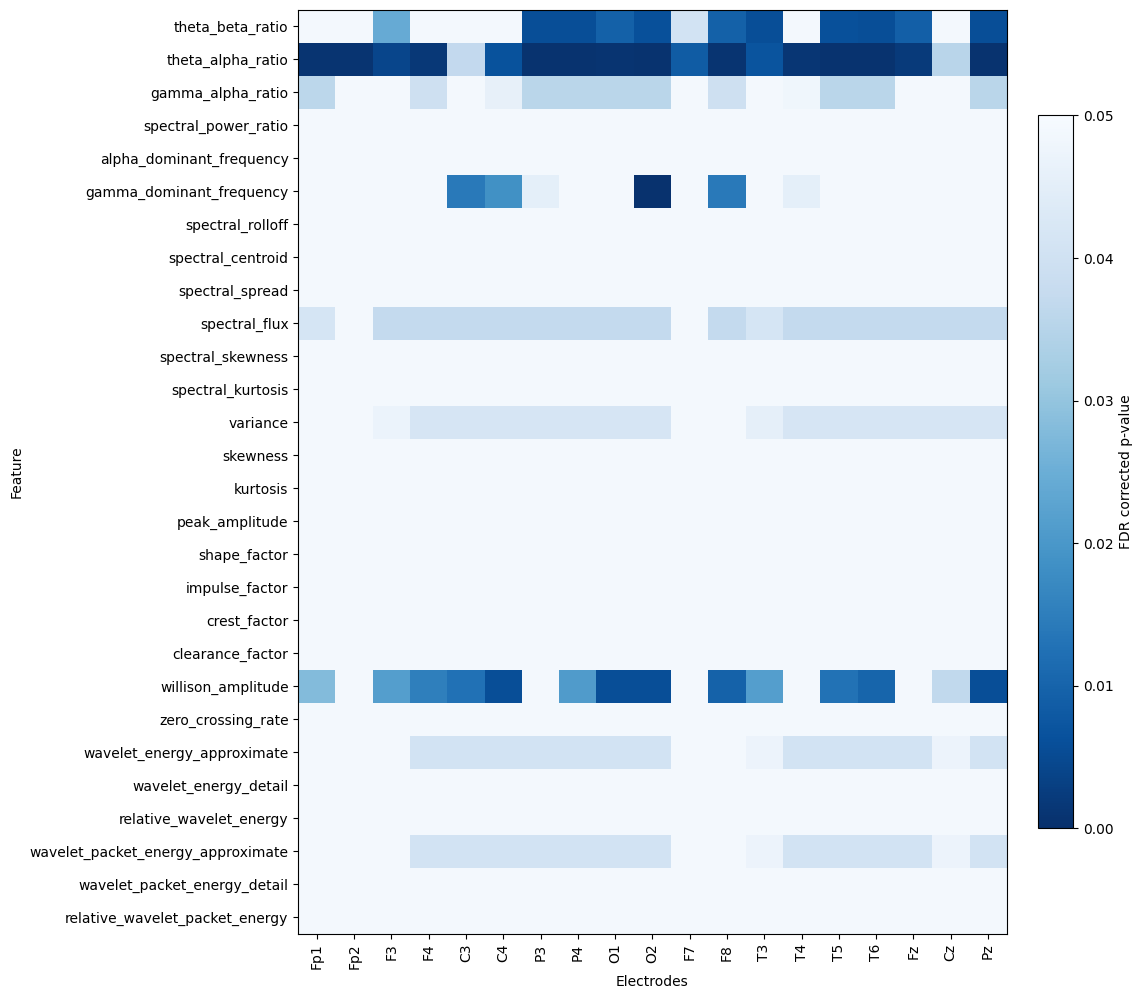

In [20]:
heatmap_df = corrected_resultsets_to_heatmap_df(
    corrected_result_set,
    feature_order=dataset.feature_names,
    channel_order=dataset.ch_names,
    value_kind="p_value_corrected",
    mask_nonsignificant=True,
    nonsignificant_fill_value=0.049,
)

plot_feature_heatmap(heatmap_df)

In [17]:
dethamp_dataset.participant_datasets[0].features_df

,theta_beta_ratio,theta_alpha_ratio,gamma_alpha_ratio,spectral_power_ratio,alpha_dominant_frequency,gamma_dominant_frequency,spectral_rolloff,spectral_centroid,spectral_spread,spectral_flux,...,crest_factor,clearance_factor,willison_amplitude,zero_crossing_rate,wavelet_energy_approximate,wavelet_energy_detail,relative_wavelet_energy,wavelet_packet_energy_approximate,wavelet_packet_energy_detail,relative_wavelet_packet_energy
Fp1,0.016583,0.169186,9.412634,53.761979,12.516249,38.632046,52.981567,36.673639,22.506866,1.488864e-06,...,3.985381,5.942168,29801.0,0.152295,7.311721e-07,5.230472e-08,0.933240,7.311721e-07,5.230472e-08,0.933240
Fp2,0.017061,0.197493,11.574531,54.569639,12.516249,39.265358,51.581614,35.554954,21.134040,1.572196e-06,...,3.791773,5.666136,29807.0,0.151528,7.672068e-07,5.249929e-08,0.935954,7.672068e-07,5.249929e-08,0.935954
F3,0.009464,0.079248,5.890212,91.910532,12.516249,32.215593,50.781641,37.075983,20.143866,8.023664e-07,...,3.564228,5.216001,29836.0,0.159695,5.140249e-07,3.730815e-08,0.932331,5.140249e-07,3.730815e-08,0.932331
F4,0.010958,0.097771,5.348434,84.933625,12.516249,31.048965,50.781641,34.845022,21.964385,6.472189e-07,...,3.349677,4.943201,29807.0,0.151328,3.674285e-07,2.373643e-08,0.939319,3.674285e-07,2.373643e-08,0.939319
C3,0.010095,0.072275,3.537410,101.855164,12.516249,33.965534,50.448318,38.966856,19.852817,5.482421e-07,...,3.251203,4.697291,29887.0,0.171828,4.327085e-07,3.223446e-08,0.930670,4.327085e-07,3.223446e-08,0.930670
C4,0.009917,0.098534,4.757414,92.555556,12.516249,31.848938,51.514950,34.888138,23.396337,6.132082e-07,...,3.177660,4.710630,29805.0,0.150195,3.203997e-07,2.028220e-08,0.940466,3.203997e-07,2.028220e-08,0.940466
P3,0.010901,0.082481,3.853021,88.912997,12.516249,39.415353,50.481651,38.550731,20.223112,5.805622e-07,...,3.191879,4.645112,29865.0,0.169161,4.067727e-07,2.939512e-08,0.932606,4.067727e-07,2.939512e-08,0.932606
P4,0.010533,0.096795,4.139155,92.078930,12.516249,31.848938,50.498317,35.545263,21.492285,5.642041e-07,...,3.166112,4.662656,29836.0,0.157195,3.420543e-07,2.253165e-08,0.938199,3.420543e-07,2.253165e-08,0.938199
O1,0.011389,0.130418,8.381103,69.704890,12.516249,39.415353,52.448252,35.010356,22.880647,8.296590e-07,...,3.580261,5.336223,29723.0,0.147162,4.299951e-07,2.968382e-08,0.935425,4.299951e-07,2.968382e-08,0.935425
O2,0.009763,0.105548,6.070544,84.342210,12.516249,39.415353,51.298290,34.480402,23.250038,6.934400e-07,...,3.328150,4.936215,29793.0,0.150328,3.822747e-07,2.512201e-08,0.938335,3.822747e-07,2.512201e-08,0.938335
